In [1]:
# Importar librerias necesarias
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.api.types import is_float_dtype, is_integer_dtype

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.Routes import RUTAS

In [2]:
# Carga de datos
df = pd.read_excel(RUTAS['data_raw'] / 'Dirty_Sales_Marketing_Dataset.xlsx')
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001.0,MALE,nan,India,Berlin,2022-05-10,2024-12-31,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002.0,nan,35.0,Germany,Mumbai,2024-06-16,2024-05-07,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003.0,female,27.0,Germany,NaN,2023-08-23,2024-04-28,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004.0,FEMALE,36.0,India,Mumbai,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005.0,MALE,29.0,USA,Hamburg,2023-07-21,2024-04-07,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [3]:
# Vista general del dataset
print('Shape dataset completo:', df.shape)
print('Cantidad de columnas:', len(df.columns))
print('Columnas del dataset:')
print(df.columns.tolist())

Shape dataset completo: (15750, 30)
Cantidad de columnas: 30
Columnas del dataset:
['customer_id', 'gender', 'age', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'coupon_code', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


In [4]:
# Revisión de estructura y tipos de datos del dataset
print('INFO del dataset:')
print(df.info())

print('\nTipos de datos por columna:')
print(df.dtypes)

INFO del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 15750 entries, 0 to 15749
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 15750 non-null  str           
 1   gender                      15750 non-null  str           
 2   age                         15750 non-null  str           
 3   country                     14165 non-null  str           
 4   city                        14185 non-null  str           
 5   signup_date                 15750 non-null  datetime64[us]
 6   last_purchase_date          15750 non-null  datetime64[us]
 7   acquisition_channel         15750 non-null  str           
 8   device_type                 15750 non-null  str           
 9   subscription_type           15750 non-null  str           
 10  is_premium_user             15750 non-null  int64         
 11  total_visits                15750 non-null  int

In [5]:
# Conteo de valores nulos
df.isnull().sum().sort_values(ascending=False)

coupon_code                   6445
country                       1585
city                          1565
total_spent                   1110
satisfaction_score             736
gender                           0
last_purchase_date               0
acquisition_channel              0
device_type                      0
subscription_type                0
is_premium_user                  0
customer_id                      0
age                              0
signup_date                      0
pages_per_session                0
avg_session_time                 0
total_visits                     0
email_click_rate                 0
avg_order_value                  0
discount_used                    0
support_tickets                  0
email_open_rate                  0
refund_requested                 0
delivery_delay_days              0
payment_method                   0
nps_score                        0
marketing_spend_per_user         0
lifetime_value                   0
last_3_month_purchas

In [6]:
# Estadísticas descriptivas del dataset
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,15750,13250,nan,1056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,15750,8,male,4573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,15750,78,nan,1844,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,14165,5,Germany,2883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,14185,7,London,2122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,15750,NaN,NaN,NaN,2023-05-15 22:34:14.400000,2022-01-01 00:00:00,2022-09-05 00:00:00,2023-05-20 00:00:00,2024-01-21 00:00:00,2024-09-26 00:00:00,NaN
last_purchase_date,15750,NaN,NaN,NaN,2024-02-05 08:48:05.485714,2023-01-01 00:00:00,2023-07-18 00:00:00,2024-02-08 00:00:00,2024-08-25 00:00:00,2025-03-10 00:00:00,NaN
acquisition_channel,15750,5,Organic,3211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,15750,3,Tablet,5296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,15750,2,Monthly,8029,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# seleccion de columnas numericas
columnas_numericas = []
for col in df.columns:
    if is_float_dtype(df[col]) or is_integer_dtype(df[col]):
        columnas_numericas.append(col)
print('Columnas numéricas identificadas:', columnas_numericas)

Columnas numéricas identificadas: ['is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


In [8]:
# Detección de outliers por IQR para las columnas numéricas
filas_outliers = []

for columna in columnas_numericas:

    serie = pd.to_numeric(df[columna], errors='coerce')
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad_outliers = int(((serie < limite_inferior) | (serie > limite_superior)).sum())
    filas_outliers.append({'columna': columna, 'outliers_iqr': cantidad_outliers, 'lim_inf': limite_inferior, 'lim_sup': limite_superior})

df_outliers = pd.DataFrame(filas_outliers).sort_values('outliers_iqr', ascending=False)
df_outliers

,columna,outliers_iqr,lim_inf,lim_sup
17,churn,2415,0.000000,0.000000
10,refund_requested,2324,0.000000,0.000000
12,satisfaction_score,791,1.500000,5.500000
11,delivery_delay_days,195,-1.000000,7.000000
9,support_tickets,85,-2.000000,6.000000
6,total_spent,85,-303.763329,1304.722034
15,lifetime_value,58,-665.864653,3082.784948
7,avg_order_value,57,-7.747431,127.634267
2,avg_session_time,46,-0.128945,16.172719
1,total_visits,42,3.000000,27.000000


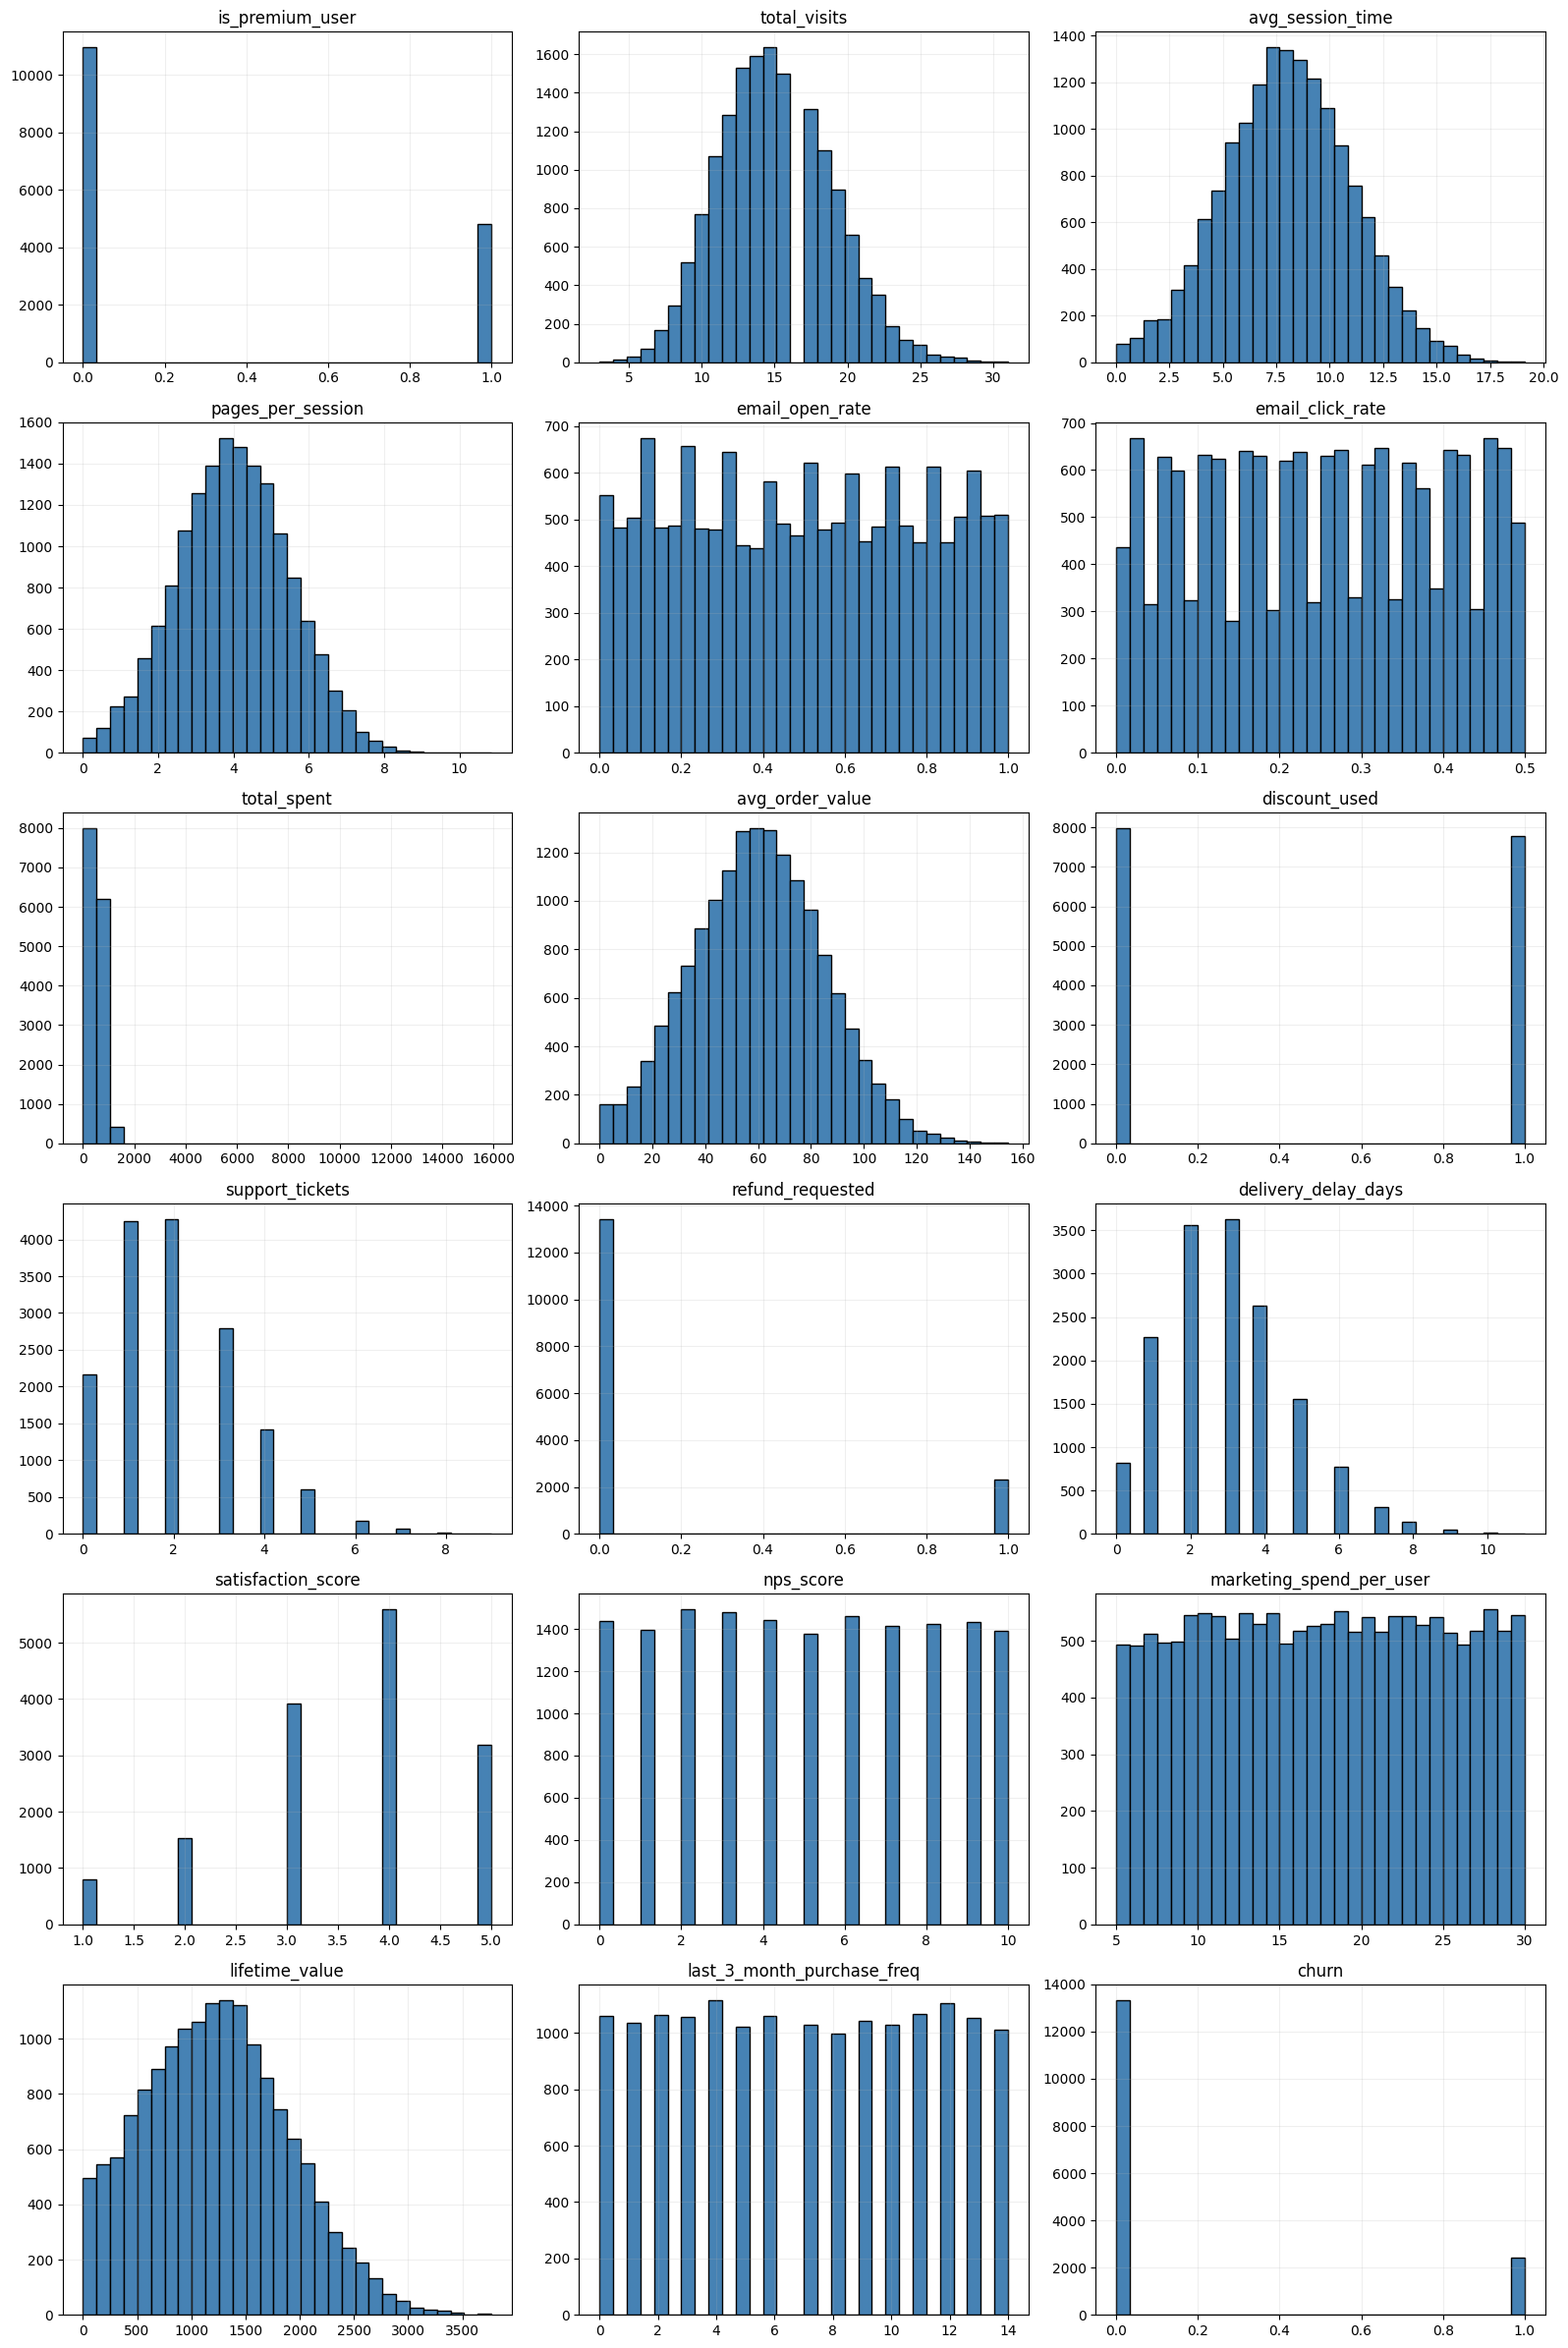

In [9]:
# Distribuciones numéricas (histogramas)
n_cols = len(columnas_numericas)
ncols = 3
nrows = int(np.ceil(n_cols / ncols))

fig, ejes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
ejes = np.atleast_1d(ejes).flatten()

for indice, columna in enumerate(columnas_numericas):
    pd.to_numeric(df[columna], errors='coerce').hist(
        ax=ejes[indice], bins=30, color='steelblue', edgecolor='black'
    )
    ejes[indice].set_title(columna)
    ejes[indice].grid(alpha=0.2)

# Oculta ejes sobrantes cuando la grilla es mayor al número de variables
for i in range(n_cols, len(ejes)):
    ejes[i].set_visible(False)

plt.tight_layout()
plt.show()

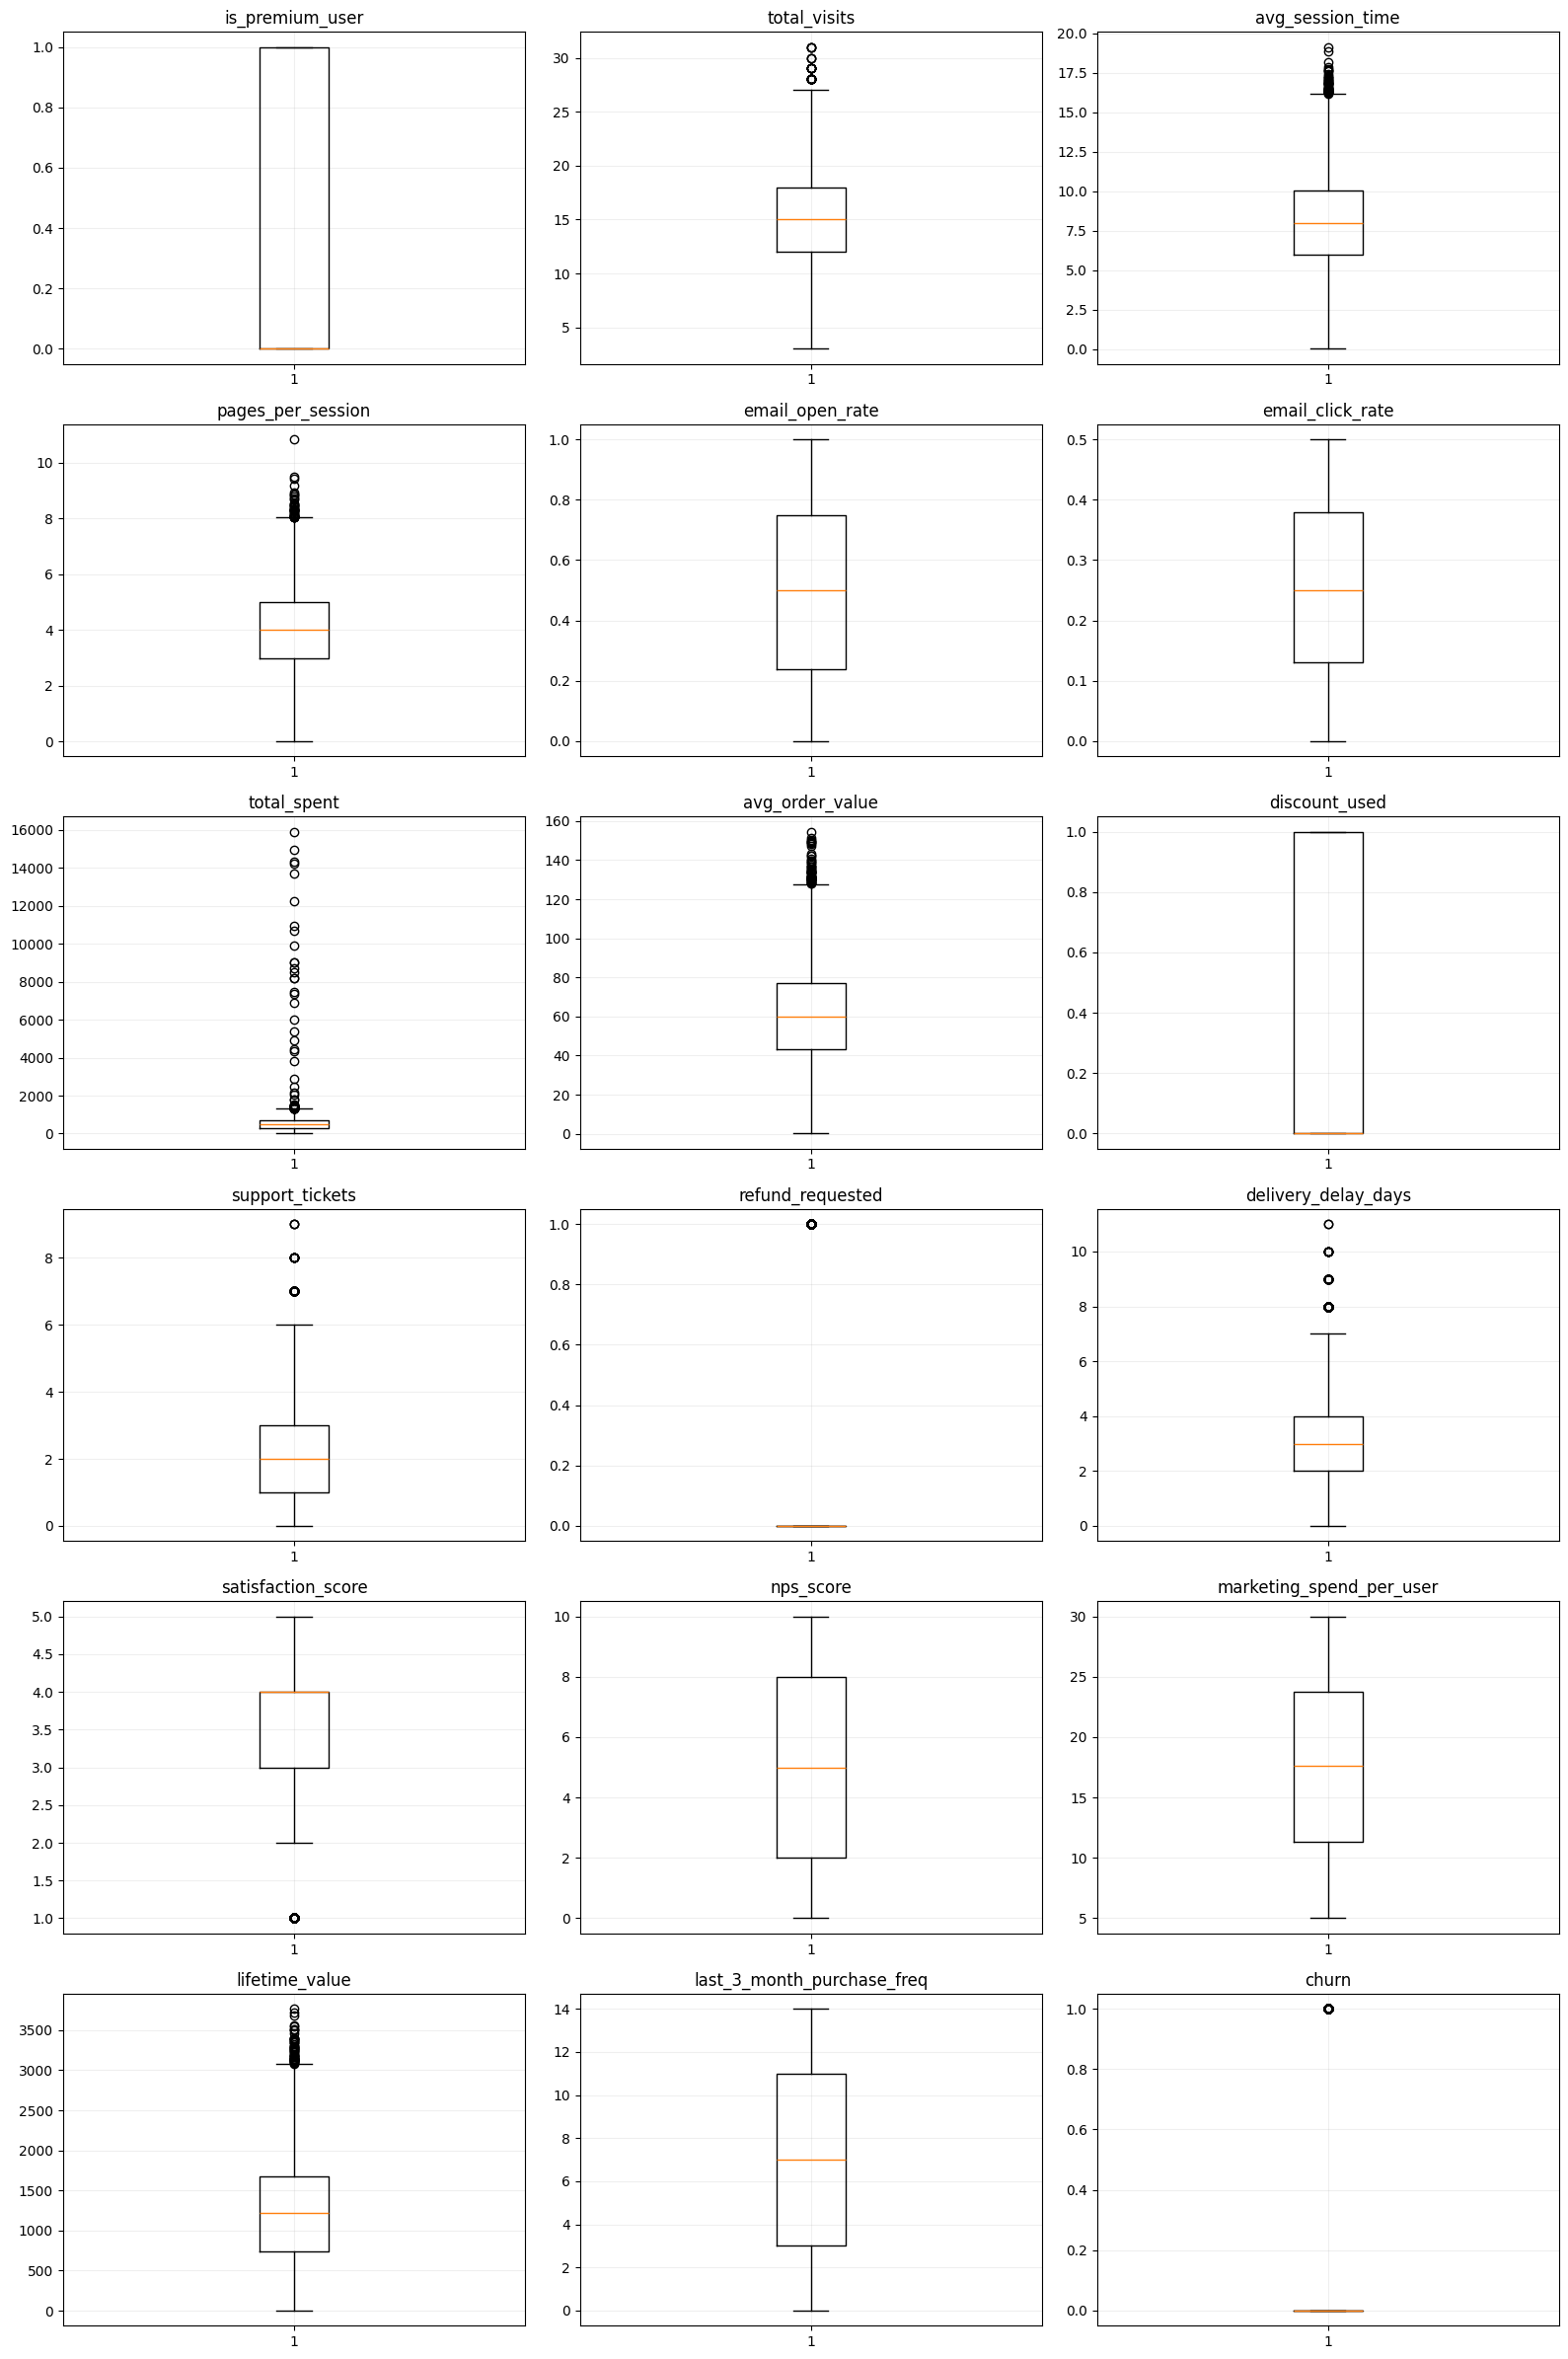

In [10]:
# Boxplots para inspección visual de outliers
n_cols = len(columnas_numericas)
ncols = 3
nrows = int(np.ceil(n_cols / ncols))

fig, ejes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
ejes = np.atleast_1d(ejes).flatten()

for indice, columna in enumerate(columnas_numericas):
    ejes[indice].boxplot(pd.to_numeric(df[columna], errors='coerce').dropna(), vert=True)
    ejes[indice].set_title(columna)
    ejes[indice].grid(alpha=0.2)

# Oculta ejes sobrantes cuando la grilla es mayor al número de variables
for i in range(n_cols, len(ejes)):
    ejes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# Revisión de correlacon entre variables numéricas
df.corr('spearman',numeric_only=True)

,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
is_premium_user,1.000000,0.017527,0.002475,0.004252,-0.002841,-0.004938,0.008463,0.004211,0.008122,0.010220,0.003569,-0.007384,-0.001720,-0.006424,0.014045,0.008325,-0.001484,-0.008247
total_visits,0.017527,1.000000,-0.001652,0.007531,-0.005101,0.009899,0.004935,-0.011858,-0.005358,0.000422,-0.001399,0.005255,-0.012425,0.001708,0.012242,-0.009448,-0.004997,0.017302
avg_session_time,0.002475,-0.001652,1.000000,-0.002942,0.006850,0.006695,0.009530,-0.001690,-0.000108,0.007149,-0.004253,-0.007495,-0.012205,-0.007649,-0.009069,0.001423,-0.000863,0.017903
pages_per_session,0.004252,0.007531,-0.002942,1.000000,-0.006176,0.003574,-0.006452,-0.000123,0.009849,0.010725,-0.004243,0.009523,-0.014497,0.003380,0.002461,0.001063,-0.001309,0.003855
email_open_rate,-0.002841,-0.005101,0.006850,-0.006176,1.000000,0.001809,0.000209,-0.001322,-0.010159,0.000032,0.012462,-0.003159,-0.001428,-0.009439,0.006808,0.004084,-0.015167,-0.008424
email_click_rate,-0.004938,0.009899,0.006695,0.003574,0.001809,1.000000,0.014403,0.002579,-0.017140,-0.013978,0.003293,0.008419,-0.000029,-0.012652,0.001524,-0.021998,-0.001377,-0.000619
total_spent,0.008463,0.004935,0.009530,-0.006452,0.000209,0.014403,1.000000,-0.000748,-0.007351,-0.000877,-0.008321,0.011458,-0.004968,0.004090,0.010664,-0.008881,-0.005800,-0.257136
avg_order_value,0.004211,-0.011858,-0.001690,-0.000123,-0.001322,0.002579,-0.000748,1.000000,-0.020508,-0.002415,0.001794,0.003762,-0.013859,0.004864,0.004983,-0.005943,0.001275,0.000015
discount_used,0.008122,-0.005358,-0.000108,0.009849,-0.010159,-0.017140,-0.007351,-0.020508,1.000000,0.013609,0.004661,0.006762,0.001287,0.004301,-0.003805,0.007271,0.000039,-0.001034
support_tickets,0.010220,0.000422,0.007149,0.010725,0.000032,-0.013978,-0.000877,-0.002415,0.013609,1.000000,0.009128,0.014895,0.004775,-0.003336,-0.001621,0.006159,-0.001621,0.086818


## EDA focalizado en 20 columnas seleccionadas
A partir del análisis general del dataset, se profundiza en las 15 variables numéricas y 5 categóricas elegidas para el informe, incluyendo nulos, tipos de datos, visualizaciones y detección de outliers por IQR.

In [12]:
# Selección de columnas a utilizar, para este dataset se utilizarán: 15 numéricas y 5 categóricas
columnas_numericas = [
    'age', 'total_spent', 'avg_order_value', 'lifetime_value',
    'last_3_month_purchase_freq', 'marketing_spend_per_user',
    'total_visits', 'avg_session_time', 'pages_per_session',
    'email_open_rate', 'email_click_rate', 'support_tickets',
    'delivery_delay_days', 'satisfaction_score', 'nps_score'
]

columnas_categoricas = ['gender', 'country', 'acquisition_channel', 'subscription_type', 'payment_method']
columnas_seleccionadas = columnas_numericas + columnas_categoricas

print('Columnas numéricas seleccionadas:', columnas_numericas)
print('\nColumnas categóricas seleccionadas:', columnas_categoricas)

Columnas numéricas seleccionadas: ['age', 'total_spent', 'avg_order_value', 'lifetime_value', 'last_3_month_purchase_freq', 'marketing_spend_per_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'support_tickets', 'delivery_delay_days', 'satisfaction_score', 'nps_score']

Columnas categóricas seleccionadas: ['gender', 'country', 'acquisition_channel', 'subscription_type', 'payment_method']


In [13]:
# Frecuencias absolutas de categóricas
for columna in columnas_categoricas:
    print(f'\n{columna}')
    print(df[columna].value_counts(dropna=False))


gender
gender
male       4573
female     4401
FEMALE     1930
MALE       1906
nan        1554
NAN         687
other       497
OTHER       202
Name: count, dtype: int64

country
country
Germany       2883
Bangladesh    2833
India         2822
USA           2816
UK            2811
NaN           1585
Name: count, dtype: int64

acquisition_channel
acquisition_channel
Organic         3211
Google Ads      3185
Facebook Ads    3170
Referral        3108
Email           3076
Name: count, dtype: int64

subscription_type
subscription_type
Monthly    8029
Annual     7721
Name: count, dtype: int64

payment_method
payment_method
UPI       3266
PayPal    3162
SEPA      3118
BKash     3114
Card      3090
Name: count, dtype: int64


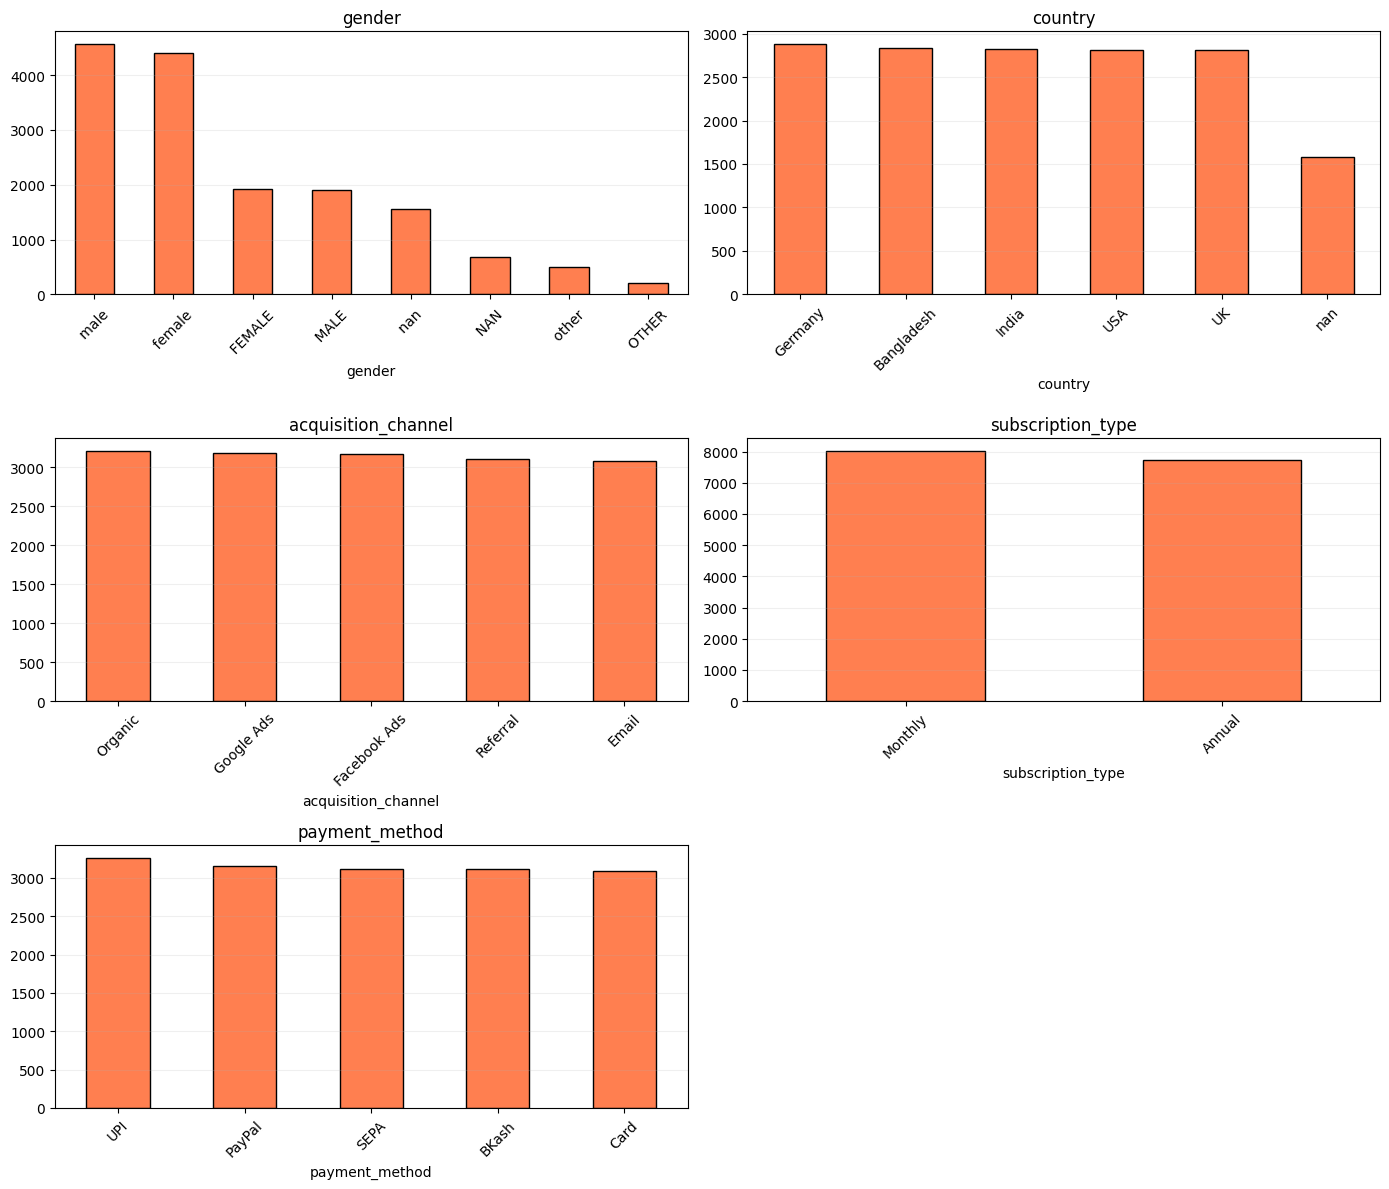

In [14]:
# Visualización de categóricas (top categorías)
fig, ejes = plt.subplots(3, 2, figsize=(14, 12))
ejes = ejes.flatten()

for indice, columna in enumerate(columnas_categoricas):
    conteo_valores = df[columna].astype(str).value_counts(dropna=False).head(10)
    conteo_valores.plot(kind='bar', ax=ejes[indice], color='coral', edgecolor='black')
    ejes[indice].set_title(columna)
    ejes[indice].tick_params(axis='x', rotation=45)
    ejes[indice].grid(axis='y', alpha=0.2)

# Oculta el subplot sobrante
if len(columnas_categoricas) < len(ejes):
    for indice in range(len(columnas_categoricas), len(ejes)):
        ejes[indice].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
# Resumen rápido por columna numérica: tipo, nulos y posible señal de outliers (IQR)
resumen_rapido_numerico = []
for columna in columnas_numericas:
    serie = pd.to_numeric(df[columna], errors='coerce')
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad_outliers = int(((serie < limite_inferior) | (serie > limite_superior)).sum())
    resumen_rapido_numerico.append({
        'columna': columna,
        'dtype': str(df[columna].dtype),
        'nulos': int(df[columna].isnull().sum()),
        'outliers_iqr': cantidad_outliers
    })

pd.DataFrame(resumen_rapido_numerico).sort_values(['outliers_iqr', 'nulos'], ascending=False)

,columna,dtype,nulos,outliers_iqr
13,satisfaction_score,float64,736,791
0,age,str,0,399
12,delivery_delay_days,int64,0,195
1,total_spent,float64,1110,85
11,support_tickets,int64,0,85
3,lifetime_value,float64,0,58
2,avg_order_value,float64,0,57
7,avg_session_time,float64,0,46
6,total_visits,int64,0,42
8,pages_per_session,float64,0,39


In [16]:
# Resumen rápido por columna categórica: tipo, nulos y cardinalidad
resumen_rapido_categorico = []
for columna in columnas_categoricas:
    resumen_rapido_categorico.append({
        'columna': columna,
        'dtype': str(df[columna].dtype),
        'nulos': int(df[columna].isnull().sum()),
        'unicos': int(df[columna].nunique(dropna=True))
    })

pd.DataFrame(resumen_rapido_categorico).sort_values(['nulos', 'unicos'], ascending=False)

,columna,dtype,nulos,unicos
1,country,str,1585,5
0,gender,str,0,8
2,acquisition_channel,str,0,5
4,payment_method,str,0,5
3,subscription_type,str,0,2
